> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 5: EDA

## Outline

- Univariate analysis (distributions, histograms, counts)
- Bivariate analysis (correlations, scatterplots, group comparisons)
- Reflections and insights

This lab uses the same dataset from **Lab 4**. You will see some overlap in the initial tasks as the data is cleaned.  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## SF Rentals - Business Context

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (price) can be compared with property features like size (sqft), bedrooms and bathrooms, and whether the listing is a full apartment or just a room; location data (nhood, lat, lon) allows for geographic analysis of rent differences across neighborhoods; and time variables (date, year) help track how the market changes over time. Text fields like title and descr can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which neighborhoods are most expensive, or how prices have changed over time. This kind of analysis is valuable for setting competitive prices, identifying investment opportunities, and helping renters or companies make informed housing decisions.

Note that many of the columns (variables) will be empty.  This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent.  Each row represents one rental listing.

**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018. Retrieved from [Github](https://github.com/katepennington/historic_bay_area_craigslist_housing_posts/blob/master/clean_2000_2018.csv.zip).

## Data Dictionary

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1)|
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## 1. Importing the Data

### Instructions:
- Import the `pandas` library for dataframes.  Then `Matplotlib` and `Seaborn` for data visualization.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

/tmp/ipykernel_2442/4027342650.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [3]:
# Get summary info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  object 
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8015 non-null    object 
dtypes: float64(8), object(9)
memory usage: 26.0+ MB


In [4]:
# Preview the first rows
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


## 2. Inspecting Data Quality

### Instructions:
- Check for outliers or invalid data in key numeric variables like `price`, `sqft`, `beds`, or `baths`.  The techniques for dealing with outliers will be covered more in week 6.  This week we will just look for outliers, but we won't take steps to change or remove them.    

In [5]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


### Reflection:
- 2.1 Do any numeric variables contain extreme or unusual values?
- 2.2 Should those outlier values be removed?  Or are they valid rental properties?

### ✍️ Your Response: 🔧
2.1 Yes. The maximum rental price is $40,000 of $1,800.

The maximum rental price is $40,000 compared to a median of $1,800. The largest property is listed at 900,000 square feet, which is unusually high compared to the median of 1,000 square feet. There are also listings with up to 12 bedrooms and 8 bathrooms.

2.2  I would investigate the outliers before removing them. Some expensive listings may be legitimate luxury properties, but 900,000 square feet is likely a data-entry error. I would check the original listings before deciding whether to remove any records.

## 3. Univariate Analysis

Explore individual variables to understand their distributions and frequency.

### Tasks:
- Plot histograms for numeric variables (`price`, `sqft`)
- Plot countplots for categorical variables (`beds`, `nhood`)


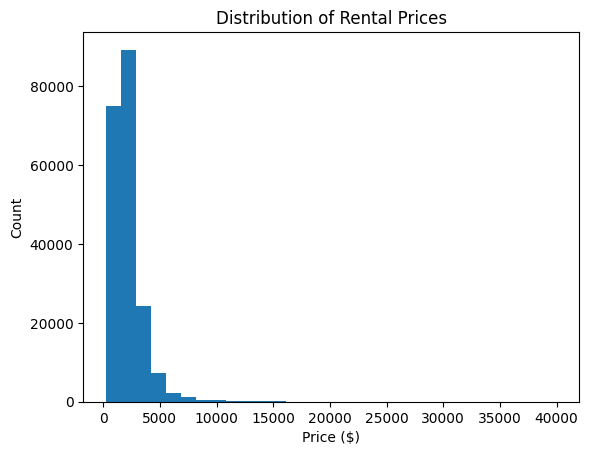

In [6]:
# Histogram: Price
plt.hist(df['price'], bins=30)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

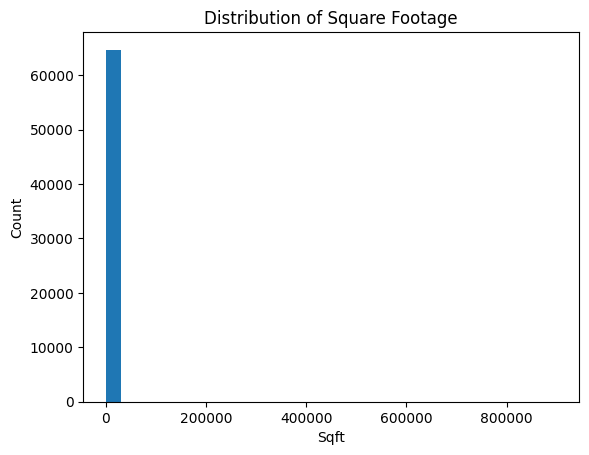

In [7]:
# Histogram: Square Footage
plt.hist(df['sqft'].dropna(), bins=30)
plt.title("Distribution of Square Footage")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.show()


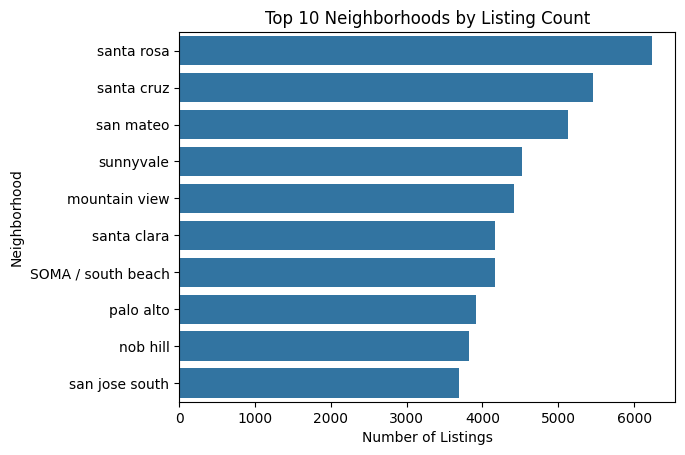

In [8]:
# Bar plot of top 10 neighborhoods by number of listings
top_nhoods = df['nhood'].value_counts().head(10)

sns.barplot(x=top_nhoods.values, y=top_nhoods.index)
plt.title("Top 10 Neighborhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")
plt.show()

### 🔧 Do the following – Part 3

1. Create two new visualizations using different variables than the ones already shown above.

>Suggestions:
- A **histogram** of the `baths` variable
- A **bar chart** showing the **average square footage by number of bathrooms**

> Be sure to label your axes and include a title for each chart.

### Reflection:

After creating each of the visuals, write 1–2 sentences explaining what you notice in each.


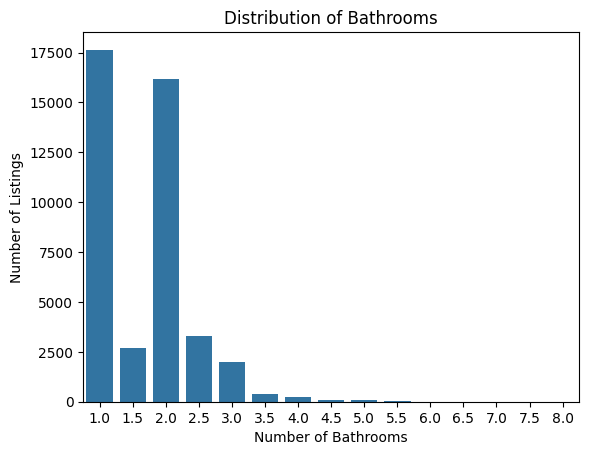

baths
1.0    17644
1.5     2710
2.0    16172
2.5     3309
3.0     2016
3.5      386
4.0      258
4.5       73
5.0       71
5.5       17
6.0       11
6.5        4
7.0        2
7.5        1
8.0        1
Name: count, dtype: int64


In [9]:

# Visual 1: Distribution of bathrooms
sns.countplot(data=df, x="baths")

plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Listings")
plt.show()

print(df["baths"].value_counts().sort_index())


### ✍️ Visual 1 Response: 🔧
1. Most rental listings with bathroom information have either 1 or 2 bathrooms, with 17,644 and 16,172 listings, respectively. Properties with 3 or more bathrooms are much less common, and only one listing has 8 bathrooms.

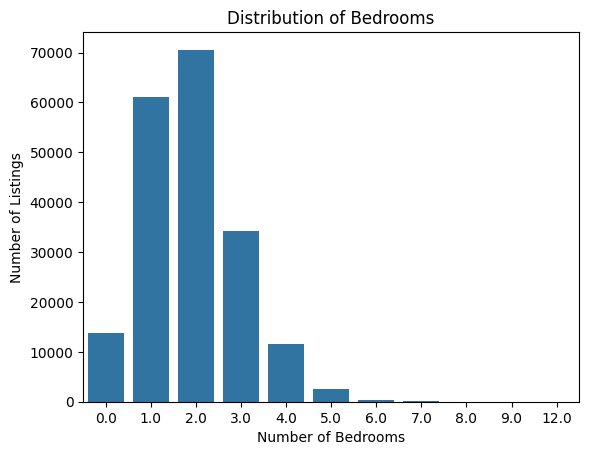

beds
0.0     13730
1.0     61090
2.0     70575
3.0     34253
4.0     11493
5.0      2604
6.0       321
7.0        83
8.0        32
9.0         4
12.0        3
Name: count, dtype: int64


In [10]:

# Visual 2: Distribution of bedrooms
sns.countplot(data=df, x="beds")

plt.title("Distribution of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Listings")
plt.show()

print(df["beds"].value_counts().sort_index())


### ✍️ Visual 2 Response: 🔧
1. Most rental listings have 2 bedrooms (70,575 listings), followed by 1 bedroom (61,090 listings). Listings with 4 or more bedrooms are much less common, suggesting that smaller rental properties make up most of the dataset.

## 4. Bivariate Analysis

Explore relationships between two variables to understand how features like square footage or bedrooms influence price.


In [11]:
# Correlation matrix
corr_matrix = df[['price', 'beds', 'baths', 'sqft']].corr()
corr_matrix


,price,beds,baths,sqft
price,1.000000,0.450096,0.433553,0.074310
beds,0.450096,1.000000,0.651835,0.707235
baths,0.433553,0.651835,1.000000,0.645372
sqft,0.074310,0.707235,0.645372,1.000000


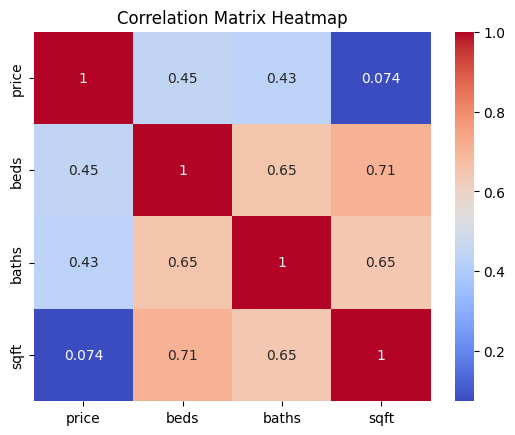

In [12]:
# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

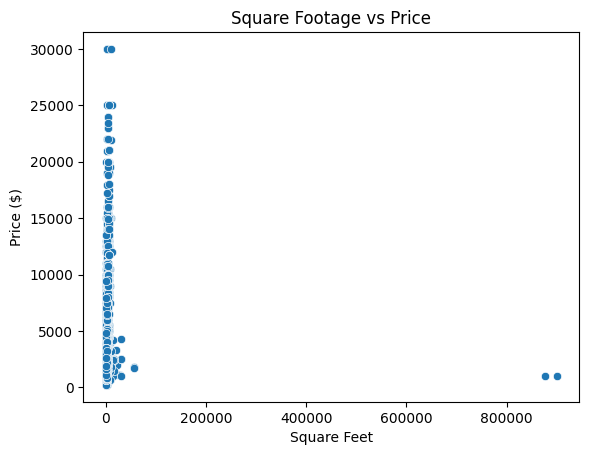

In [13]:
# Scatterplot: Square Footage vs Price
sns.scatterplot(x='sqft', y='price', data=df)
plt.title("Square Footage vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.show()

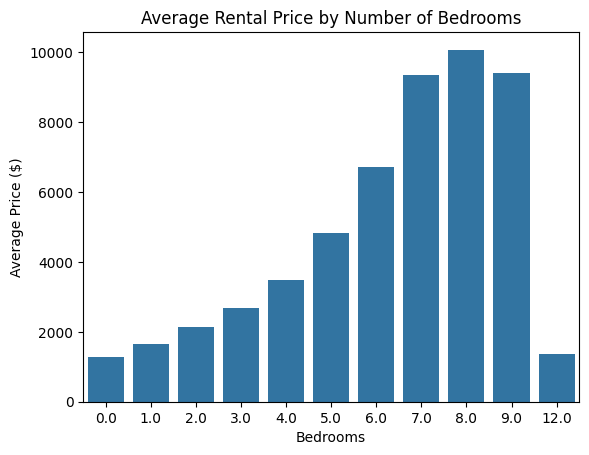

In [14]:
# Average price by number of bedrooms
avg_price_beds = df.groupby('beds')['price'].mean().sort_index()
sns.barplot(x=avg_price_beds.index, y=avg_price_beds.values)
plt.title("Average Rental Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")
plt.show()

### 🔧 Do the following – Part 4

- 4.1 Create a scatterplot of `baths` vs `price`.  
- 4.2 Group by `year` and plot the average price over time.

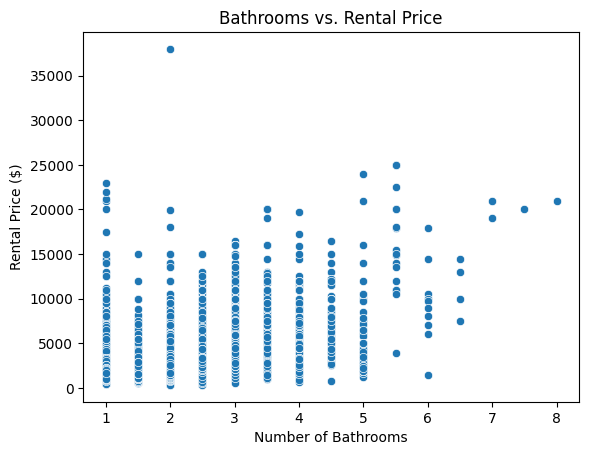

Average rental price by year:
year
2000.0    1418.70
2001.0    2070.04
2002.0    1709.35
2003.0    1587.71
2004.0    1640.21
2005.0    1525.48
2006.0    1822.99
2007.0    2152.30
2008.0    2067.77
2009.0    1951.87
2010.0    1831.30
2011.0    2082.87
2012.0    2126.31
2013.0    2679.82
2014.0    2799.56
2015.0    3016.06
2016.0    2892.95
2017.0    2998.66
2018.0    2967.05
Name: price, dtype: float64


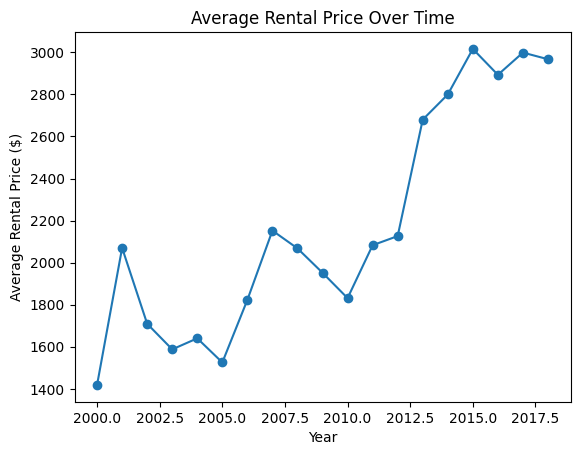

Average price by number of bathrooms:
baths
1.0     1856.62
1.5     2139.98
2.0     2543.40
2.5     2963.69
3.0     3753.27
3.5     5239.77
4.0     4996.66
4.5     6699.68
5.0     5422.17
5.5    15873.24
6.0     9463.18
6.5    11248.75
7.0    20000.00
7.5    20000.00
8.0    20950.00
Name: price, dtype: float64
Correlation matrix:
       price   beds  baths   sqft
price  1.000  0.450  0.434  0.074
beds   0.450  1.000  0.652  0.707
baths  0.434  0.652  1.000  0.645
sqft   0.074  0.707  0.645  1.000


In [15]:

# 4.1 Scatterplot: Bathrooms vs. Price
sns.scatterplot(data=df, x="baths", y="price")

plt.title("Bathrooms vs. Rental Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Rental Price ($)")
plt.show()

# 4.2 Average rental price by year
avg_price_year = df.groupby("year")["price"].mean()

print("Average rental price by year:")
print(avg_price_year.round(2))

plt.plot(avg_price_year.index, avg_price_year.values,
         marker="o")
plt.title("Average Rental Price Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rental Price ($)")
plt.show()

# Additional summary for the reflection
print("Average price by number of bathrooms:")
print(df.groupby("baths")["price"].mean().round(2))

print("Correlation matrix:")
print(df[["price", "beds", "baths", "sqft"]].corr().round(3))


### Reflection:
4.1 What trends or outliers do you see?

### ✍️ Your Response: 🔧
4.1 Rental prices generally increase as the number of bathrooms increases. Listings with one bathroom averaged $1,856.62, while listings with three bathrooms averaged $3,753.27. Properties with five or more bathrooms have some unusually high prices, including an average of $20,950 for eight bathrooms. However, there are very few listings with that many bathrooms, so these averages may not represent typical rental properties.

## 🔧  Part 5: Reflection

Answer the following questions in the markdown cell below (no more than a few sentences per question required)

- 5.1 Which variables are most strongly correlated with rental price?
- 5.2 Are there patterns in how size (sqft) or number of bedrooms affects price?
- 5.3 Which neighborhoods or years show the highest prices?
- 5.4 What other visualizations or groupings might improve this analysis?

Use this section to summarize insights from both Labs 4 and 5.

### ✍️ Your Response: 🔧
5.1  Bedrooms and bathrooms have the strongest correlations with rental price, at 0.450 and 0.434, respectively. Square footage has a much weaker correlation of 0.074, which may be affected by extreme outliers or missing data.

5.2 Rental prices generally increase as the number of bedrooms increases. Bedrooms have a moderate positive correlation with price (0.450). Square footage has a weak correlation with price (0.074), potentially because of extreme values such as the 900,000-square-foot listing.

5.3 The neighborhoods with the highest average rental prices were Atherton ($4,536.01), Tiburon/Belvedere ($4,265.35), and the Financial District ($3,958.16), among neighborhoods with at least 20 listings. The year with the highest average rental price was 2015 at $3,016.06, followed by 2017 at $2,998.66. These findings show that rental prices vary significantly by location and have changed over time.Copy answer

5.4 A bar chart comparing average rental prices by neighborhood would help identify the most expensive areas. Boxplots showing prices by bedroom count could reveal differences in pricing and highlight outliers. I would also investigate extreme square-footage values to better understand the relationship between property size and rental price.


## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [ ]:
!jupyter nbconvert --to html "lab_05_eda.ipynb"

In [16]:

# Top 10 neighborhoods by average rental price
nhood_prices = (
    df.groupby("nhood")["price"]
    .agg(["mean", "count"])
    .query("count >= 20")
    .sort_values("mean", ascending=False)
    .head(10)
)

display(nhood_prices.round(2))


,mean,count
nhood,,
atherton,4536.01,182
tiburon / belvedere,4265.35,880
financial district,3958.16,762
west portal / forest hills,3827.28,402
saratoga,3801.85,389
kentfield / ross,3611.58,289
los altos,3605.05,871
SOMA / south beach,3585.90,4163
pacific heights,3487.85,3487
